# Model Building & Evaluation

## Objective

The objective of this notebook is to build multiple machine learning models to predict customer churn and compare their performance.

Models:

- Logistic Regression
- Decision Tree
- Random Forest

Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The best-performing model will be selected for business interpretation and dashboard integration.

In [3]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()

y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [4]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

## Logistic Regression

In [5]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [6]:
y_pred_log = log_model.predict(X_test)

y_prob_log = log_model.predict_proba(X_test)[:,1]

In [7]:
log_accuracy = accuracy_score(y_test, y_pred_log)

log_precision = precision_score(y_test, y_pred_log)

log_recall = recall_score(y_test, y_pred_log)

log_f1 = f1_score(y_test, y_pred_log)

log_auc = roc_auc_score(y_test, y_prob_log)

In [8]:
print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision : {log_precision:.4f}")
print(f"Recall : {log_recall:.4f}")
print(f"F1 Score : {log_f1:.4f}")
print(f"ROC AUC : {log_auc:.4f}")

Accuracy : 0.8034
Precision : 0.6502
Recall : 0.5615
F1 Score : 0.6026
ROC AUC : 0.8465


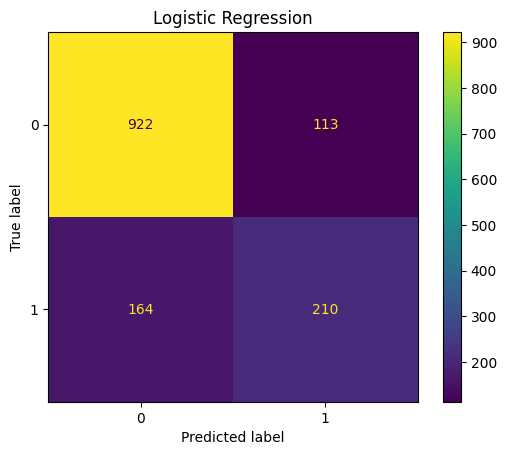

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log
)

plt.title("Logistic Regression")

plt.show()

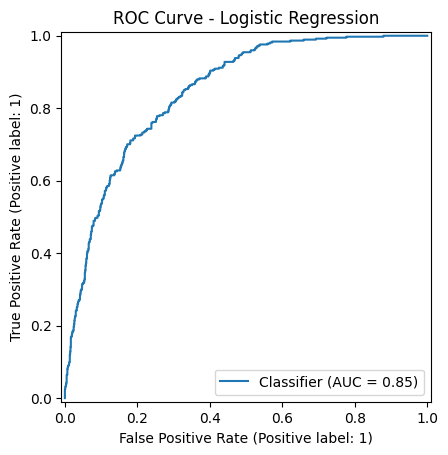

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_log
)

plt.title("ROC Curve - Logistic Regression")

plt.show()

## Decision Tree

In [11]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [12]:
y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:,1]

In [13]:
dt_accuracy = accuracy_score(y_test,y_pred_dt)

dt_precision = precision_score(y_test,y_pred_dt)

dt_recall = recall_score(y_test,y_pred_dt)

dt_f1 = f1_score(y_test,y_pred_dt)

dt_auc = roc_auc_score(y_test,y_prob_dt)

In [14]:
print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC AUC : {dt_auc:.4f}")

Accuracy : 0.7339
Precision : 0.4987
Recall : 0.5187
F1 Score : 0.5085
ROC AUC : 0.6658


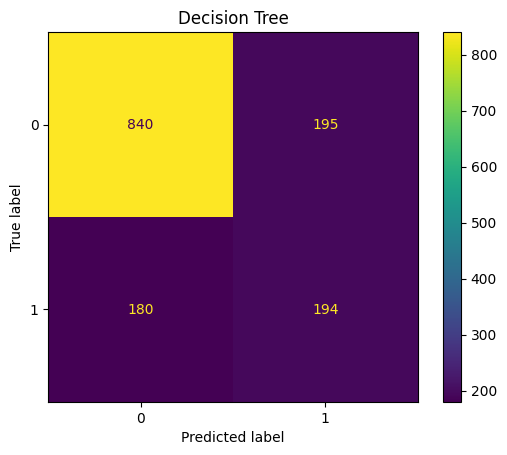

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt
)

plt.title("Decision Tree")

plt.show()

## Random Forest

In [16]:
rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [17]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [18]:
rf_accuracy = accuracy_score(y_test,y_pred_rf)

rf_precision = precision_score(y_test,y_pred_rf)

rf_recall = recall_score(y_test,y_pred_rf)

rf_f1 = f1_score(y_test,y_pred_rf)

rf_auc = roc_auc_score(y_test,y_prob_rf)

In [19]:
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC AUC : {rf_auc:.4f}")

Accuracy : 0.7991
Precision : 0.6585
Recall : 0.5053
F1 Score : 0.5719
ROC AUC : 0.8357


In [20]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],

    "Precision":[
        log_precision,
        dt_precision,
        rf_precision
    ],

    "Recall":[
        log_recall,
        dt_recall,
        rf_recall
    ],

    "F1 Score":[
        log_f1,
        dt_f1,
        rf_f1
    ],

    "ROC-AUC":[
        log_auc,
        dt_auc,
        rf_auc
    ]

})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8034,0.6502,0.5615,0.6026,0.8465
1,Decision Tree,0.7339,0.4987,0.5187,0.5085,0.6658
2,Random Forest,0.7991,0.6585,0.5053,0.5719,0.8357


# Model Selection

Three machine learning algorithms were evaluated for customer churn prediction.

Although Random Forest achieved the highest Precision, Logistic Regression outperformed the other models in terms of:

- Accuracy
- Recall
- F1 Score
- ROC-AUC Score

Since customer churn prediction focuses on identifying customers likely to leave, Recall and ROC-AUC are particularly important.

Therefore, Logistic Regression was selected as the final predictive model for this project.

In [24]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(

    by="Importance",

    ascending=False

)

feature_importance.head(10)

,Feature,Importance
17,Monthly Charges,0.171934
4,Tenure Months,0.168951
18,Total Charges,0.162260
14,Contract,0.082394
16,Payment Method,0.050538
8,Online Security,0.049186
11,Tech Support,0.041149
3,Dependents,0.039082
9,Online Backup,0.027786
0,Gender,0.027637


In [28]:
feature_importance.to_csv(
    "../data/processed/feature_importance.csv",
    index=False
)

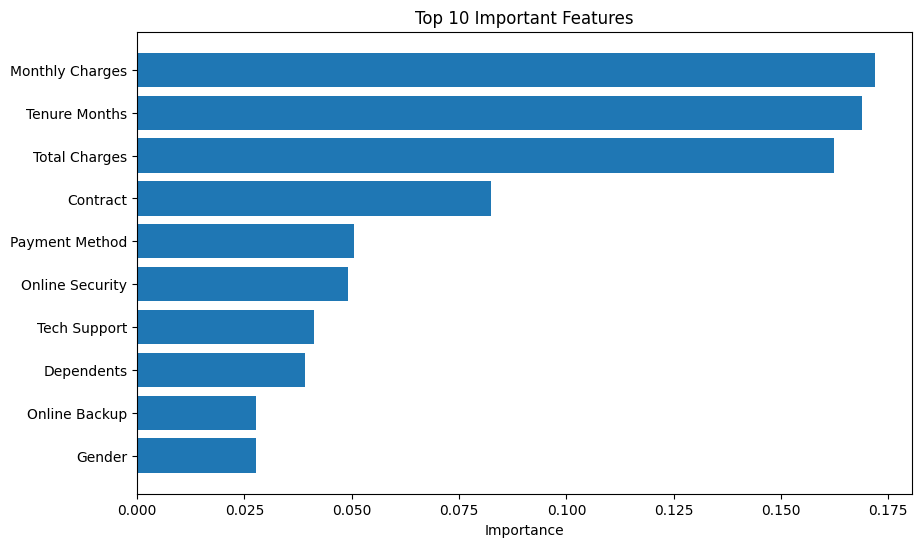

In [25]:
plt.figure(figsize=(10,6))

plt.barh(

    feature_importance["Feature"][:10],

    feature_importance["Importance"][:10]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance")

plt.show()

# Model Evaluation Summary

Three machine learning models were developed and evaluated.

The evaluation metrics indicate the strengths and weaknesses of each model.

The model with the best balance of Accuracy, Recall, Precision, and ROC-AUC will be selected for churn prediction and business decision-making.

Feature Importance analysis highlights the variables that contribute most significantly to customer churn.

# Final Model Selection

Based on the evaluation metrics, **Logistic Regression** was selected as the final model for customer churn prediction.

### Reasons for Selection

- Highest Accuracy (80.34%)
- Highest Recall (56.15%)
- Highest F1 Score (60.26%)
- Highest ROC-AUC Score (84.65%)

Although Random Forest achieved slightly higher Precision, Logistic Regression provided a better overall balance between identifying churned customers and minimizing prediction errors.

Since customer churn prediction prioritizes identifying customers who are likely to leave, Recall and ROC-AUC were considered more important than Precision alone.

Therefore, Logistic Regression was selected as the final predictive model for this project.

In [27]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        log_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        log_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        log_f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        log_auc,
        dt_auc,
        rf_auc
    ]
})

comparison = comparison.round(4)

comparison.style\
    .background_gradient(cmap="Blues", subset=["Accuracy","Precision","Recall","F1 Score","ROC-AUC"])\
    .format({
        "Accuracy":"{:.4f}",
        "Precision":"{:.4f}",
        "Recall":"{:.4f}",
        "F1 Score":"{:.4f}",
        "ROC-AUC":"{:.4f}"
    })

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8034,0.6502,0.5615,0.6026,0.8465
1,Decision Tree,0.7339,0.4987,0.5187,0.5085,0.6658
2,Random Forest,0.7991,0.6585,0.5053,0.5719,0.8357


# Conclusion

Three supervised machine learning models were developed and evaluated to predict customer churn.

Key observations:

- Logistic Regression delivered the best overall predictive performance.
- Decision Tree showed comparatively lower performance across all evaluation metrics.
- Random Forest achieved strong Precision but slightly lower Recall and ROC-AUC than Logistic Regression.

The selected model can help businesses proactively identify customers at high risk of churn, enabling targeted retention strategies, personalized offers, and improved customer relationship management.

The insights generated in this notebook will be used in the next stage to derive business recommendations and build an interactive Power BI dashboard.